In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path


def load_roi(path="mihi_roi_postel_px.npz"):
    d = np.load(path)

    return {
        "px": d["px"],
        "py": d["py"],
        "map_shape": tuple(d["map_shape"]),
        "lon_carr": float(d["lon_carr"]),
        "lat_carr": float(d["lat_carr"]),
    }


def check_shape(emap, shape_ref):
    if emap.shape != shape_ref:
        raise ValueError(
            f"Mapa {emap.shape} ≠ mapa de referencia {shape_ref}"
        )


def roi_mask(px, py, shape):
    """
    Máscara booleana.
    True para los píxeles cuyo centro está dentro de la ROI.
    """
    ny, nx = shape

    yy, xx = np.mgrid[0:ny, 0:nx]

    poly = Path(
        np.column_stack([px, py])
    )

    inside = poly.contains_points(
        np.column_stack([
            xx.ravel(),
            yy.ravel()
        ])
    )

    return inside.reshape(shape)


def plot_roi(ax, px, py, **kw):

    kw.setdefault("color", "cyan")
    kw.setdefault("lw", 1.5)

    ax.plot(px, py, **kw)

In [7]:
# ============================================================
# LOAD MiHI ROI IN POSTEL PIXEL COORDINATES
# ============================================================

roi = load_roi("mihi_roi_postel_px.npz")

px_roi = roi["px"]
py_roi = roi["py"]

# Validate the ROI reference geometry
check_shape(egression_maps[0], roi["map_shape"])

print("MiHI ROI loaded successfully")
print("ROI reference shape:", roi["map_shape"])
print("ROI boundary points:", len(px_roi))

MiHI ROI loaded successfully
ROI reference shape: (1024, 1024)
ROI boundary points: 401


In [1]:
import numpy as np

# ============================================================
# LOAD PERSISTENT PORE MASKS
# ============================================================

pores_file = "../data/2018_08_25/pores/persistent_pore_tracks_4.npz"

pores = np.load(pores_file)

# Pore identifiers
pore_ids = pores["pore_ids"]
track_ids = pores["track_ids"]

# Spatial properties across reference frames
frames = pores["frames"]

x_centers = pores["x_centers"]
y_centers = pores["y_centers"]
radii = pores["radii"]

# Original and equivalent circular masks
region_masks = pores["masks"]
circle_masks = pores["circle_masks"]

print("Number of pores:", len(pore_ids))
print("Reference frames:", frames[0])
print("Region masks shape:", region_masks.shape)
print("Circle masks shape:", circle_masks.shape)

Number of pores: 34
Reference frames: [   0  480  960 1440]
Region masks shape: (34, 4, 1024, 1024)
Circle masks shape: (34, 4, 1024, 1024)


In [2]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

files = {
    "2.0-3.0 mHz": "egress_pwr_02.0-03.0mHz_z0000km.fits",
    "3.0-4.0 mHz": "egress_pwr_03.0-04.0mHz_z0000km.fits",
    "4.0-5.0 mHz": "egress_pwr_04.0-05.0mHz_z0000km.fits",
    "5.0-6.0 mHz": "egress_pwr_05.0-06.0mHz_z0000km.fits",
    "6.0-7.0 mHz": "egress_pwr_06.0-07.0mHz_z0000km.fits",
    "7.0-8.0 mHz": "egress_pwr_07.0-08.0mHz_z0000km.fits",
    "8.0-9.0 mHz": "egress_pwr_08.0-09.0mHz_z0000km.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km.fits",
    "10.0-11.0 mHz": "egress_pwr_10.0-11.0mHz_z0000km.fits",
}
frequencies = list(files.keys())

egression_maps = []

for freq_band, filename in files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    egression_maps.append(data_map)

print("Number of maps:", len(egression_maps))
print("Shape of first map:", egression_maps[0].shape)

Number of maps: 9
Shape of first map: (1024, 1024)


In [9]:
import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# SELECT PORES BY MAGNETIC-FIELD RANKING
# ============================================================

# Selected pore IDs (ranking positions)
selected_pore_ids = [1] + list(range(4, 33, 4))

# Find their corresponding indices in the NPZ arrays
selected_indices = np.where(
    np.isin(pore_ids, selected_pore_ids)
)[0]

# ============================================================
# CREATE SUMMARY DATAFRAME
# ============================================================

selected_pores_df = pd.DataFrame({
    "Pore ID": pore_ids[selected_indices],
    "Track ID": track_ids[selected_indices],
    "Mean B [G]": pores["mean_B"][selected_indices],
    "Detections": [
        len(frames[i]) for i in selected_indices
    ],
    "Mean radius [px]": np.mean(
        radii[selected_indices], axis=1
    ),
    "Mean area [px²]": np.mean(
        pores["areas"][selected_indices], axis=1
    )
})

selected_pores_df = selected_pores_df.sort_values("Pore ID")

print(f"Selected pores: {len(selected_indices)}")
display(selected_pores_df.round(2))

Selected pores: 9


,Pore ID,Track ID,Mean B [G],Detections,Mean radius [px],Mean area [px²]
0,1,60,-63.90,4,12.05,469.25
1,4,11,56.68,4,7.13,160.75
2,8,12,-51.29,4,7.31,170.75
3,12,4,-48.63,4,6.27,125.00
4,16,98,-44.77,4,7.36,176.25
5,20,79,-43.12,4,7.83,194.75
6,24,85,-40.95,4,8.94,255.00
7,28,20,-37.55,4,8.11,225.25
8,32,48,-33.30,4,7.76,197.25


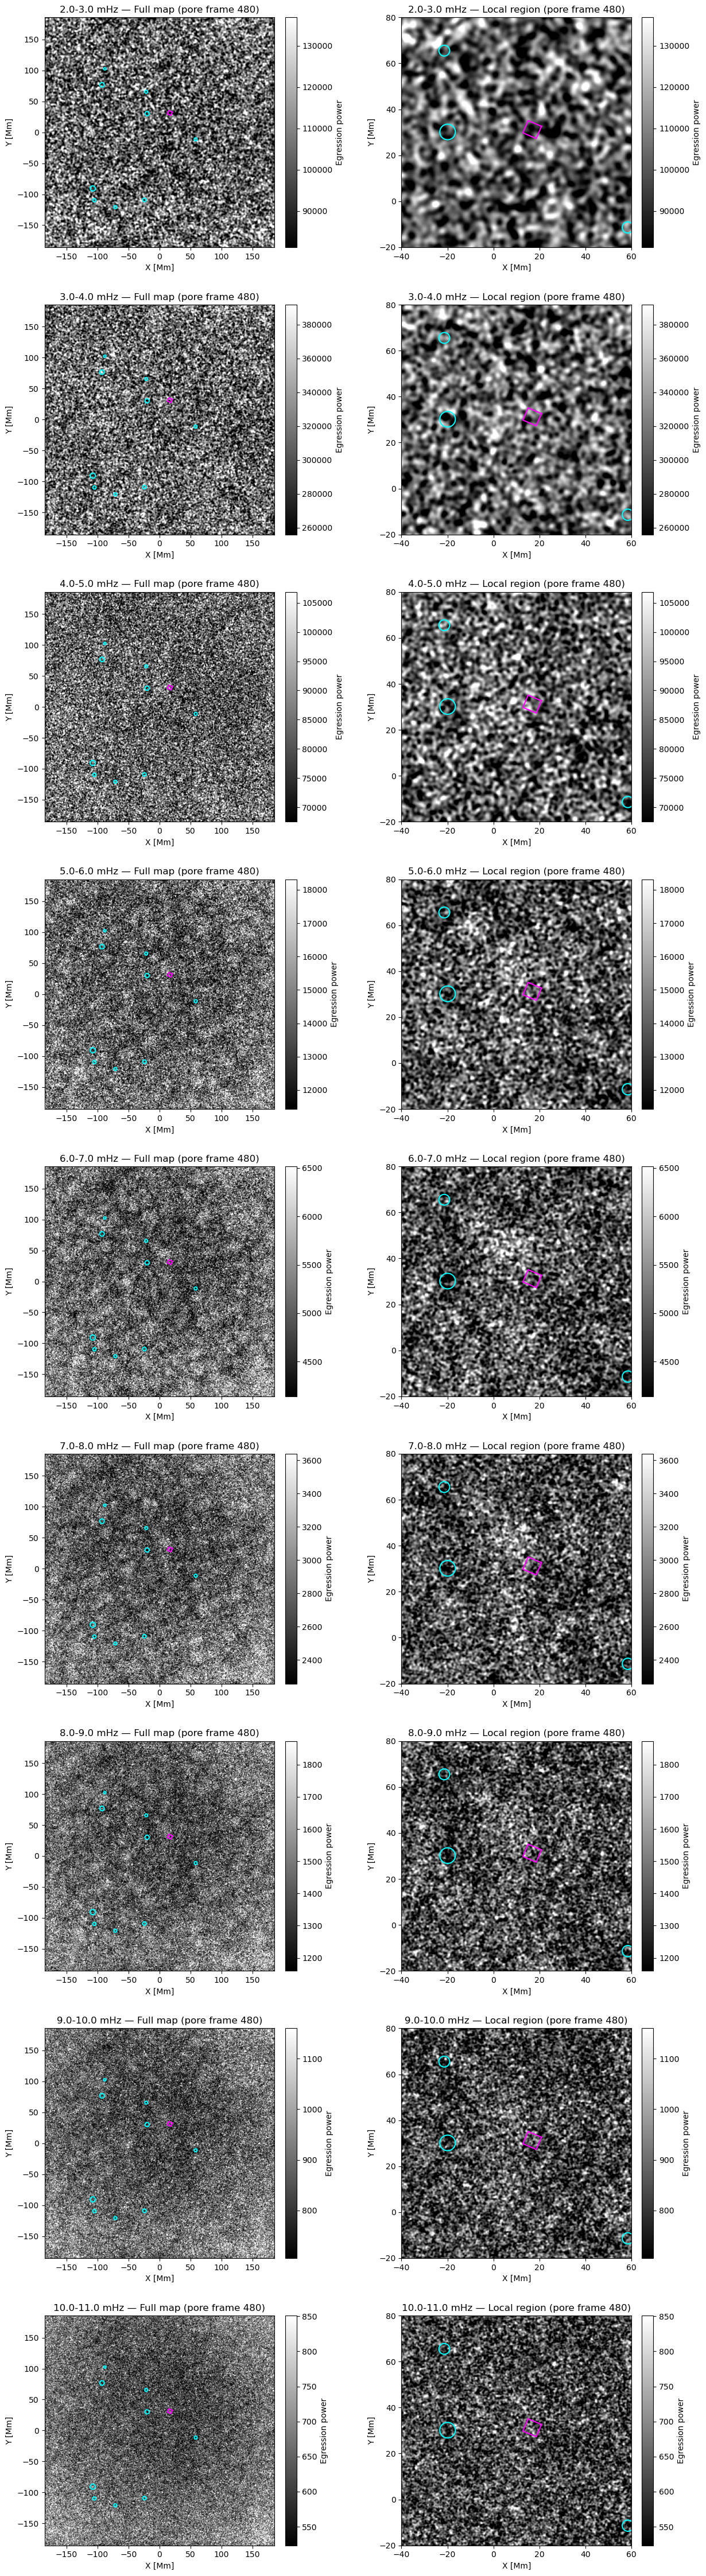

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# SELECT REFERENCE MAGNETOGRAM
# ============================================================

ref_index = 1  # 0, 1, 2, 3 -> frames 0, 480, 960, 1440

selected_frame = frames[0, ref_index]

# Use only the selected pores at the chosen reference frame
x_selected = x_centers[selected_indices, ref_index]
y_selected = y_centers[selected_indices, ref_index]
r_selected = radii[selected_indices, ref_index]

# ============================================================
# SPATIAL SCALE
# ============================================================

# HMI: 0.5 arcsec/pixel
# Approximate solar scale: 725 km/arcsec
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel


# ============================================================
# MAP GEOMETRY
# ============================================================

ny, nx = egression_maps[0].shape

x_min = -nx / 2 * spatial_sample
x_max =  nx / 2 * spatial_sample
y_min = -ny / 2 * spatial_sample
y_max =  ny / 2 * spatial_sample

extent = [x_min, x_max, y_min, y_max]


# ============================================================
# MiHI ROI: POSTEL PIXELS -> Mm
# ============================================================

x_roi_Mm = (px_roi - nx / 2) * spatial_sample
y_roi_Mm = (py_roi - ny / 2) * spatial_sample


# ============================================================
# PORES: POSTEL PIXELS -> Mm
# ============================================================

x_pores_Mm = (x_selected - nx / 2) * spatial_sample
y_pores_Mm = (y_selected - ny / 2) * spatial_sample
r_pores_Mm = r_selected * spatial_sample


# ============================================================
# FUNCTION TO PLOT PORE REGIONS
# ============================================================

def plot_pores(ax):

    for x0, y0, r in zip(
        x_pores_Mm,
        y_pores_Mm,
        r_pores_Mm
    ):

        circle = Circle(
            (x0, y0),
            r,
            fill=False,
            linewidth=1.5,
            color="cyan"
        )

        ax.add_patch(circle)


# ============================================================
# FIGURE
# ============================================================

n_maps = len(egression_maps)

fig, axes = plt.subplots(
    nrows=n_maps,
    ncols=2,
    figsize=(12, 5 * n_maps),
    squeeze=False
)


# ============================================================
# PLOT EACH FREQUENCY BAND
# ============================================================

for i, (freq, data_map) in enumerate(
    zip(frequencies, egression_maps)
):

    # Contrast limits for this frequency band
    vmin = np.nanpercentile(data_map, 5)
    vmax = np.nanpercentile(data_map, 98)

    # ========================================================
    # COLUMN 1: FULL MAP
    # ========================================================

    ax_full = axes[i, 0]

    im_full = ax_full.imshow(
        data_map,
        origin="lower",
        cmap="gray",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    # MiHI ROI
    plot_roi(
        ax_full,
        x_roi_Mm,
        y_roi_Mm,
        color="magenta",
        lw=1.5
    )

    # Persistent pores
    plot_pores(ax_full)

    ax_full.set_xlabel("X [Mm]")
    ax_full.set_ylabel("Y [Mm]")
    ax_full.set_title(
        f"{freq} — Full map (pore frame {selected_frame})"
    )

    fig.colorbar(
        im_full,
        ax=ax_full,
        label="Egression power",
        fraction=0.046,
        pad=0.04
    )

    # ========================================================
    # COLUMN 2: LOCAL REGION
    # ========================================================

    ax_zoom = axes[i, 1]

    im_zoom = ax_zoom.imshow(
        data_map,
        origin="lower",
        cmap="gray",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    # MiHI ROI
    plot_roi(
        ax_zoom,
        x_roi_Mm,
        y_roi_Mm,
        color="magenta",
        lw=1.5
    )

    # Persistent pores
    plot_pores(ax_zoom)

    # Spatial zoom
    ax_zoom.set_xlim(-40, 60)
    ax_zoom.set_ylim(-20, 80)

    ax_zoom.set_xlabel("X [Mm]")
    ax_zoom.set_ylabel("Y [Mm]")
    ax_zoom.set_title(
        f"{freq} — Local region (pore frame {selected_frame})"
    )

    fig.colorbar(
        im_zoom,
        ax=ax_zoom,
        label="Egression power",
        fraction=0.046,
        pad=0.04
    )


# ============================================================
# ADJUST SPACING
# ============================================================

plt.tight_layout()

fig.subplots_adjust(
    wspace=0.35,
    hspace=0.25
)

plt.show()

In [11]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

cropped_files = {
    "2.0-3.0 mHz":  "egress_pwr_02.0-03.0mHz_z0000km_cropped.fits",
    "3.0-4.0 mHz":  "egress_pwr_03.0-04.0mHz_z0000km_cropped.fits",
    "4.0-5.0 mHz":  "egress_pwr_04.0-05.0mHz_z0000km_cropped.fits",
    "5.0-6.0 mHz":  "egress_pwr_05.0-06.0mHz_z0000km_cropped.fits",
    "6.0-7.0 mHz":  "egress_pwr_06.0-07.0mHz_z0000km_cropped.fits",
    "7.0-8.0 mHz":  "egress_pwr_07.0-08.0mHz_z0000km_cropped.fits",
    "8.0-9.0 mHz":  "egress_pwr_08.0-09.0mHz_z0000km_cropped.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km_cropped.fits",
    "10.0-11.0 mHz":"egress_pwr_10.0-11.0mHz_z0000km_cropped.fits",
}

cropped_frequencies = list(cropped_files.keys())
cropped_maps = []

for freq_band, filename in cropped_files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    cropped_maps.append(data_map)

    n_total = data_map.size
    n_nan   = np.isnan(data_map).sum()
    n_zero  = np.sum(data_map == 0)
    n_finite = np.isfinite(data_map).sum()

In [12]:
import numpy as np
import pandas as pd

cropped_results = []

for freq, data_map in zip(cropped_frequencies, cropped_maps):

    # Excluir los ceros introducidos por la máscara
    valid_values = data_map[data_map != 0]

    cropped_results.append({
        "Frequency": freq,
        "Cropped map mean": np.mean(valid_values),
        "Cropped map std": np.std(valid_values),
        "Valid pixels": valid_values.size
    })

cropped_results_df = pd.DataFrame(cropped_results)

cropped_results_df

,Frequency,Cropped map mean,Cropped map std,Valid pixels
0,2.0-3.0 mHz,102851.679688,14498.091797,483025
1,3.0-4.0 mHz,312694.000000,36221.378906,483025
2,4.0-5.0 mHz,83052.101562,10341.964844,483025
3,5.0-6.0 mHz,14014.916016,1785.138794,483025
4,6.0-7.0 mHz,5032.001465,615.843811,483025
5,7.0-8.0 mHz,2758.739258,351.906586,483025
6,8.0-9.0 mHz,1415.001953,180.808640,483025
7,9.0-10.0 mHz,862.691223,112.960945,483025
8,10.0-11.0 mHz,636.250732,81.142303,483025


In [13]:
import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# 1. MiHI ROI MASK
# ============================================================

ny, nx = egression_maps[0].shape

check_shape(egression_maps[0], roi["map_shape"])

mihi_mask = roi_mask(px_roi, py_roi, (ny, nx))


# ============================================================
# 2. COMBINED SUPERGRANULE MASK
# ============================================================

sg = np.load("../data/2018_08_25/supergranule_masks_geometry.npz")

centers_x = sg["x"]
centers_y = sg["y"]
radii_sg = sg["radius"]

yy, xx = np.mgrid[0:ny, 0:nx]

supergranule_mask = np.zeros((ny, nx), dtype=bool)

for x0, y0, r in zip(centers_x, centers_y, radii_sg):
    supergranule_mask |= (xx - x0)**2 + (yy - y0)**2 <= r**2


# ============================================================
# 3. SELECTED PORE MASKS
# ============================================================

# Use the nine previously selected pores at the chosen reference frame
selected_circle_masks = circle_masks[selected_indices, ref_index]

selected_pore_ids = pore_ids[selected_indices]
selected_track_ids = track_ids[selected_indices]

if selected_circle_masks.shape[1:] != (ny, nx):
    raise ValueError(
        f"Pore masks shape {selected_circle_masks.shape[1:]} "
        f"!= map shape {(ny, nx)}"
    )

# Regions used for egression power measurements
regions_to_measure = {
    "Full map": None,
    "MiHI ROI": mihi_mask,
    "Supergranules": supergranule_mask,
}

for pid, pore_mask in zip(selected_pore_ids, selected_circle_masks):
    regions_to_measure[f"Pore {pid:02d}"] = pore_mask

print(f"Reference frame: {frames[0, ref_index]}")
print(f"Supergranules: {len(centers_x)} | Pixels: {supergranule_mask.sum()}")
print(f"MiHI ROI: {mihi_mask.sum()} pixels")
print(f"Selected pores: {len(selected_pore_ids)}")

for pid, tid, pore_mask in zip(
    selected_pore_ids,
    selected_track_ids,
    selected_circle_masks
):
    print(
        f"  Pore {pid:02d} (Track {tid}): "
        f"{pore_mask.sum()} pixels"
    )


# ============================================================
# 4. STATISTICS BY FREQUENCY BAND AND REGION
# ============================================================

# Exclude NaN, infinite values, and zero-valued pixels
exclude_zeros = True

rows = []

for freq, data_map in zip(frequencies, egression_maps):

    check_shape(data_map, (ny, nx))

    valid = np.isfinite(data_map)

    if exclude_zeros:
        valid &= data_map != 0

    for region, region_mask in regions_to_measure.items():

        selection = (
            valid if region_mask is None
            else valid & region_mask
        )

        values = data_map[selection]

        rows.append({
            "Frequency": freq,
            "Region": region,
            "Mean": np.mean(values) if values.size else np.nan,
            "Std": np.std(values) if values.size else np.nan,
            "Valid pixels": int(values.size),
        })

stats_long = pd.DataFrame(rows)

# Preserve the original frequency and region ordering
region_order = list(regions_to_measure.keys())

stats_long["Region"] = pd.Categorical(
    stats_long["Region"],
    categories=region_order,
    ordered=True
)

stats_long["Frequency"] = pd.Categorical(
    stats_long["Frequency"],
    categories=frequencies,
    ordered=True
)


# ============================================================
# 5. FINAL TABLES
# ============================================================

# Mean egression power
mean_table = stats_long.pivot(
    index="Frequency",
    columns="Region",
    values="Mean"
)

# Standard deviation
std_table = stats_long.pivot(
    index="Frequency",
    columns="Region",
    values="Std"
)

# Mean egression power normalized to the full-map mean
norm_table = mean_table.div(
    mean_table["Full map"],
    axis=0
)

# Combined mean and standard deviation table
wide_table = pd.concat(
    {"mean": mean_table, "std": std_table},
    axis=1
).swaplevel(axis=1)[
    [(region, stat)
     for region in region_order
     for stat in ("mean", "std")]
]

wide_table.columns = [
    f"{region} {stat}"
    for region, stat in wide_table.columns
]


# ============================================================
# 6. SAVE RESULTS
# ============================================================

out_dir = "../data/2018_08_25/pores"

stats_long.to_csv(
    f"{out_dir}/egression_stats_selected_pores_long.csv",
    index=False
)

wide_table.to_csv(
    f"{out_dir}/egression_stats_selected_pores_wide.csv"
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\nMean egression power by frequency and region:")
display(mean_table.style.format("{:.4g}"))

print("\nStandard deviation:")
display(std_table.style.format("{:.4g}"))

print("\nMean egression power normalized to the full-map mean:")
display(
    norm_table.style.format("{:.3f}").background_gradient(
        cmap="RdBu_r",
        axis=None,
        vmin=0.5,
        vmax=1.5
    )
)

Reference frame: 480
Supergranules: 44 | Pixels: 57283
MiHI ROI: 278 pixels
Selected pores: 9
  Pore 01 (Track 60): 277 pixels
  Pore 04 (Track 11): 165 pixels
  Pore 08 (Track 12): 197 pixels
  Pore 12 (Track 4): 141 pixels
  Pore 16 (Track 98): 83 pixels
  Pore 20 (Track 79): 131 pixels
  Pore 24 (Track 85): 317 pixels
  Pore 28 (Track 20): 419 pixels
  Pore 32 (Track 48): 145 pixels

Mean egression power by frequency and region:


Region,Full map,MiHI ROI,Supergranules,Pore 01,Pore 04,Pore 08,Pore 12,Pore 16,Pore 20,Pore 24,Pore 28,Pore 32
Frequency,,,,,,,,,,,,
2.0-3.0 mHz,1.04e+05,9.169e+04,1.009e+05,9.379e+04,1.026e+05,1.063e+05,1.107e+05,8.853e+04,9.788e+04,9.736e+04,9.569e+04,1.087e+05
3.0-4.0 mHz,3.13e+05,3.073e+05,3.109e+05,2.809e+05,2.792e+05,3.309e+05,3.321e+05,2.84e+05,3.231e+05,3.364e+05,2.873e+05,3.108e+05
4.0-5.0 mHz,8.361e+04,8.411e+04,8.478e+04,7.645e+04,8.625e+04,8.269e+04,8.465e+04,8.629e+04,8.773e+04,8.515e+04,8.426e+04,7.175e+04
5.0-6.0 mHz,1.425e+04,1.393e+04,1.495e+04,1.28e+04,1.43e+04,1.377e+04,1.379e+04,1.423e+04,1.324e+04,1.349e+04,1.364e+04,1.283e+04
6.0-7.0 mHz,5123,4923,5348,4350,4904,4692,4801,4723,4767,4624,4984,4381
7.0-8.0 mHz,2820,2717,2921,2461,2580,2708,2842,2665,2494,2640,2874,2499
8.0-9.0 mHz,1449,1398,1490,1246,1379,1423,1424,1374,1305,1377,1408,1301
9.0-10.0 mHz,887.7,873.6,899.5,784.3,845.8,849,834.5,850.4,775.8,849.2,872.6,824
10.0-11.0 mHz,656.1,639.1,655.1,595.7,654.6,664.6,647.8,642,592.3,600.2,676.3,581.5



Standard deviation:


Region,Full map,MiHI ROI,Supergranules,Pore 01,Pore 04,Pore 08,Pore 12,Pore 16,Pore 20,Pore 24,Pore 28,Pore 32
Frequency,,,,,,,,,,,,
2.0-3.0 mHz,1.47e+04,9542,1.388e+04,9606,8639,1.711e+04,8655,1.21e+04,7483,1.178e+04,1.017e+04,1.098e+04
3.0-4.0 mHz,3.613e+04,2.886e+04,3.584e+04,5.053e+04,1.912e+04,1.97e+04,2.631e+04,1.978e+04,2.018e+04,3.687e+04,2.962e+04,2.558e+04
4.0-5.0 mHz,1.044e+04,9388,1.055e+04,7764,9587,9862,6392,7078,7605,9591,9038,8506
5.0-6.0 mHz,1826,1436,1882,1330,1894,1345,1507,1307,1532,1497,1667,1682
6.0-7.0 mHz,630.2,568.3,629.9,551.5,508.6,492.4,438.5,620.7,627.7,429.7,527.2,401.7
7.0-8.0 mHz,365.4,314.1,363.8,309,291.7,250.7,247.6,302.1,337.7,317.7,342.7,219.2
8.0-9.0 mHz,188.8,185.8,185.2,150.9,175.2,187.9,150.6,201.7,151.1,176,181.5,175.4
9.0-10.0 mHz,119.7,92.86,115.7,97.53,114.7,108.2,90.72,89.14,96.61,104.9,111.3,111.4
10.0-11.0 mHz,86.45,80.51,83.11,66.62,85.96,78.4,83.82,93.45,67,73.51,81.49,71.73



Mean egression power normalized to the full-map mean:


Region,Full map,MiHI ROI,Supergranules,Pore 01,Pore 04,Pore 08,Pore 12,Pore 16,Pore 20,Pore 24,Pore 28,Pore 32
Frequency,,,,,,,,,,,,
2.0-3.0 mHz,1.000,0.882,0.970,0.902,0.986,1.022,1.064,0.851,0.941,0.936,0.920,1.045
3.0-4.0 mHz,1.000,0.982,0.993,0.897,0.892,1.057,1.061,0.907,1.032,1.075,0.918,0.993
4.0-5.0 mHz,1.000,1.006,1.014,0.914,1.032,0.989,1.012,1.032,1.049,1.018,1.008,0.858
5.0-6.0 mHz,1.000,0.977,1.049,0.898,1.004,0.966,0.968,0.999,0.929,0.947,0.957,0.900
6.0-7.0 mHz,1.000,0.961,1.044,0.849,0.957,0.916,0.937,0.922,0.931,0.903,0.973,0.855
7.0-8.0 mHz,1.000,0.964,1.036,0.873,0.915,0.960,1.008,0.945,0.885,0.936,1.019,0.886
8.0-9.0 mHz,1.000,0.965,1.028,0.860,0.951,0.982,0.982,0.948,0.901,0.950,0.971,0.898
9.0-10.0 mHz,1.000,0.984,1.013,0.883,0.953,0.956,0.940,0.958,0.874,0.957,0.983,0.928
10.0-11.0 mHz,1.000,0.974,0.998,0.908,0.998,1.013,0.987,0.978,0.903,0.915,1.031,0.886


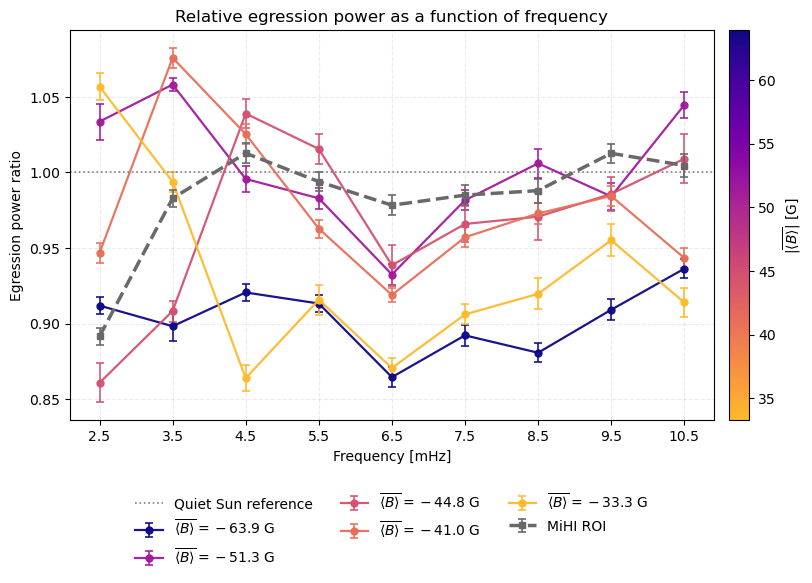

Normalized mean egression power:


Region,Pore 01,Pore 08,Pore 16,Pore 24,Pore 32,MiHI ROI
Frequency,,,,,,
2.0-3.0 mHz,0.912,1.034,0.861,0.947,1.057,0.892
3.0-4.0 mHz,0.898,1.058,0.908,1.076,0.994,0.983
4.0-5.0 mHz,0.921,0.996,1.039,1.025,0.864,1.013
5.0-6.0 mHz,0.913,0.983,1.015,0.963,0.916,0.994
6.0-7.0 mHz,0.865,0.932,0.939,0.919,0.871,0.978
7.0-8.0 mHz,0.892,0.982,0.966,0.957,0.906,0.985
8.0-9.0 mHz,0.881,1.006,0.971,0.973,0.920,0.988
9.0-10.0 mHz,0.909,0.984,0.986,0.984,0.955,1.013
10.0-11.0 mHz,0.936,1.045,1.009,0.943,0.914,1.005



Standard errors of normalized egression power:


Region,Pore 01,Pore 08,Pore 16,Pore 24,Pore 32,MiHI ROI
Frequency,,,,,,
2.0-3.0 mHz,0.0056,0.0119,0.0129,0.0064,0.0089,0.0056
3.0-4.0 mHz,0.0097,0.0045,0.0069,0.0066,0.0068,0.0055
4.0-5.0 mHz,0.0056,0.0085,0.0094,0.0065,0.0085,0.0068
5.0-6.0 mHz,0.0057,0.0068,0.0102,0.0060,0.0100,0.0061
6.0-7.0 mHz,0.0066,0.0070,0.0135,0.0048,0.0066,0.0068
7.0-8.0 mHz,0.0067,0.0065,0.0120,0.0065,0.0066,0.0068
8.0-9.0 mHz,0.0064,0.0095,0.0156,0.0070,0.0103,0.0079
9.0-10.0 mHz,0.0068,0.0089,0.0113,0.0068,0.0107,0.0065
10.0-11.0 mHz,0.0063,0.0088,0.0161,0.0065,0.0094,0.0076



Normalized egression power (mean ± SEM):


,Pore 01,Pore 08,Pore 16,Pore 24,Pore 32,MiHI ROI
Frequency,,,,,,
2.0-3.0 mHz,0.912 ± 0.006,1.034 ± 0.012,0.861 ± 0.013,0.947 ± 0.006,1.057 ± 0.009,0.892 ± 0.006
3.0-4.0 mHz,0.898 ± 0.010,1.058 ± 0.004,0.908 ± 0.007,1.076 ± 0.007,0.994 ± 0.007,0.983 ± 0.006
4.0-5.0 mHz,0.921 ± 0.006,0.996 ± 0.008,1.039 ± 0.009,1.025 ± 0.006,0.864 ± 0.009,1.013 ± 0.007
5.0-6.0 mHz,0.913 ± 0.006,0.983 ± 0.007,1.015 ± 0.010,0.963 ± 0.006,0.916 ± 0.010,0.994 ± 0.006
6.0-7.0 mHz,0.865 ± 0.007,0.932 ± 0.007,0.939 ± 0.014,0.919 ± 0.005,0.871 ± 0.007,0.978 ± 0.007
7.0-8.0 mHz,0.892 ± 0.007,0.982 ± 0.006,0.966 ± 0.012,0.957 ± 0.006,0.906 ± 0.007,0.985 ± 0.007
8.0-9.0 mHz,0.881 ± 0.006,1.006 ± 0.009,0.971 ± 0.016,0.973 ± 0.007,0.920 ± 0.010,0.988 ± 0.008
9.0-10.0 mHz,0.909 ± 0.007,0.984 ± 0.009,0.986 ± 0.011,0.984 ± 0.007,0.955 ± 0.011,1.013 ± 0.006
10.0-11.0 mHz,0.936 ± 0.006,1.045 ± 0.009,1.009 ± 0.016,0.943 ± 0.006,0.914 ± 0.009,1.005 ± 0.008


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from IPython.display import display

# ============================================================
# 1. REFERENCE: CROPPED-MAP MEAN FOR EACH FREQUENCY BAND
# ============================================================

# Match frequency bands by their labels
frequency_labels = mean_table.index.astype(str)

cropped_ref = (
    cropped_results_df
    .assign(Frequency=lambda df: df["Frequency"].astype(str))
    .set_index("Frequency")["Cropped map mean"]
    .reindex(frequency_labels)
)

if cropped_ref.isna().any():
    missing = list(cropped_ref[cropped_ref.isna()].index)
    raise ValueError(
        f"Missing cropped-map reference for bands: {missing}"
    )

if (cropped_ref <= 0).any():
    raise ValueError("Cropped-map reference values must be positive.")

# Central frequency of each band
freq_centers = np.array([
    np.mean([
        float(v)
        for v in f.replace(" mHz", "").split("-")
    ])
    for f in frequency_labels
])


# ============================================================
# 2. EGRESSION POWER RATIOS RELATIVE TO CROPPED MAPS
# ============================================================

ratio_table = mean_table.div(
    cropped_ref.to_numpy(),
    axis=0
)

ratio_table = ratio_table.drop(columns="Full map")
ratio_table.index = frequency_labels


# ============================================================
# 3. STANDARD ERRORS OF NORMALIZED EGRESSION POWER
# ============================================================

# Number of valid pixels per frequency band and region
n_table = stats_long.pivot(
    index="Frequency",
    columns="Region",
    values="Valid pixels"
)

# Align the pixel counts with the mean and standard deviation tables
n_table = n_table.reindex(
    index=mean_table.index,
    columns=mean_table.columns
)

# Standard error of the mean: SEM = std / sqrt(N)
sem_table = std_table.div(
    np.sqrt(n_table.replace(0, np.nan))
)

# Normalize the SEM using the cropped-map mean
# The uncertainty of the reference is not included here
ratio_error_table = sem_table.div(
    cropped_ref.to_numpy(),
    axis=0
)

ratio_error_table = ratio_error_table.drop(
    columns="Full map"
)

ratio_error_table.index = frequency_labels


# ============================================================
# 4. SELECT PERSISTENT PORES
# ============================================================

# Pores identified by their original magnetic-field ranking
selected_pore_ids = [1, 8, 16, 24, 32]

selected_indices_plot = np.array([
    np.where(pore_ids == pid)[0][0]
    for pid in selected_pore_ids
])

selected_pores = [
    f"Pore {pid:02d}"
    for pid in selected_pore_ids
]

# Signed time-averaged magnetic field across reference frames
selected_mean_B = pores["mean_B"][selected_indices_plot]

# Check that the selected pores are present in the ratio tables
required_regions = selected_pores + ["MiHI ROI"]

missing_regions = [
    name for name in required_regions
    if name not in ratio_table.columns
]

if missing_regions:
    raise ValueError(
        f"Missing regions in ratio table: {missing_regions}"
    )


# ============================================================
# 5. SAVE NORMALIZED EGRESSION POWER AND UNCERTAINTIES
# ============================================================

out_dir = Path("../data/2018_08_25/pores")
out_dir.mkdir(parents=True, exist_ok=True)

ratio_table.to_csv(
    out_dir / "egression_ratio_cropped_selected_pores.csv"
)

ratio_error_table.to_csv(
    out_dir / "egression_ratio_cropped_selected_pores_sem.csv"
)


# ============================================================
# 6. PORE COLORS BASED ON MEAN MAGNETIC FIELD
# ============================================================

# Color according to the absolute value of the signed
# time-averaged magnetic field, preserving its sign in labels

base = mpl.colors.LinearSegmentedColormap.from_list(
    "plasma_cut",
    plt.get_cmap("plasma")(np.linspace(0.0, 0.85, 256))
)

cmap = base.reversed()

color_values = np.abs(selected_mean_B)

norm = mpl.colors.Normalize(
    vmin=color_values.min(),
    vmax=color_values.max()
)

pore_colors = cmap(norm(color_values))


# ============================================================
# 7. PLOT RELATIVE EGRESSION POWER WITH ERROR BARS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6.5))

# Selected persistent pores
for name, mean_B, color in zip(
    selected_pores,
    selected_mean_B,
    pore_colors
):

    ax.errorbar(
        freq_centers,
        ratio_table[name].to_numpy(dtype=float),
        yerr=ratio_error_table[name].to_numpy(dtype=float),
        fmt="o-",
        markersize=5,
        linewidth=1.6,
        elinewidth=1.2,
        capsize=3,
        capthick=1.2,
        alpha=0.95,
        color=color,
        label=fr"$\overline{{\langle B\rangle}} = {mean_B:+.1f}$ G"
    )

# MiHI ROI
ax.errorbar(
    freq_centers,
    ratio_table["MiHI ROI"].to_numpy(dtype=float),
    yerr=ratio_error_table["MiHI ROI"].to_numpy(dtype=float),
    fmt="s--",
    markersize=5,
    linewidth=2.5,
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    color="dimgray",
    label="MiHI ROI ",
    zorder=5
)

# Cropped-map reference
ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.2,
    color="gray",
    label="Quiet Sun reference"
)


# ============================================================
# 8. COLORBAR
# ============================================================

sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    r"$|\overline{\langle B\rangle}|$ [G]"
)


# ============================================================
# 9. PLOT FORMATTING
# ============================================================

ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel("Egression power ratio")

ax.set_xticks(freq_centers)

ax.set_title(
    "Relative egression power as a function of frequency"
)

ax.grid(
    alpha=0.25,
    linestyle="--"
)

# ============================================================
# LEGEND BELOW THE FIGURE
# ============================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=10,
    frameon=False
)

# Reserve space below the axes for the legend
fig.subplots_adjust(bottom=0.28)

plt.show()


# ============================================================
# 10. DISPLAY RATIO AND UNCERTAINTY TABLES
# ============================================================

print("Normalized mean egression power:")

display(
    ratio_table[required_regions]
    .style.format("{:.3f}")
    .background_gradient(
        cmap="RdBu_r",
        axis=None,
        vmin=0.5,
        vmax=1.5
    )
)

print("\nStandard errors of normalized egression power:")

display(
    ratio_error_table[required_regions]
    .style.format("{:.4f}")
)

# Combined table with ratios and uncertainties
ratio_with_errors = pd.DataFrame(
    index=ratio_table.index
)

for region in required_regions:
    ratio_with_errors[region] = [
        f"{r:.3f} ± {e:.3f}"
        for r, e in zip(
            ratio_table[region],
            ratio_error_table[region]
        )
    ]

print("\nNormalized egression power (mean ± SEM):")
display(ratio_with_errors)